# Parameter settings

In [ ]:
#################### Params ###############
import sys
import os
NOVA_HOME = "/home/projects/hornsteinlab/Collaboration/NOVA"
NOVA_DATA_HOME = '/home/projects/hornsteinlab/Collaboration/NOVA/input'
sys.path.insert(1, NOVA_HOME)
print(f"NOVA_HOME: {NOVA_HOME}")
DATA_DIR = "/home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD"
RAW_DATASET_NAME = "sorted"
PROC_DATASET_NAME = "RANBP17_exp"
BATCH ="batch3"
BRENNER_CALCULATE_DATE = f"2026-05-28_RESCALE0.0-100.0_{BATCH}" 
preprocessing_path = os.path.join(NOVA_HOME, 'outputs', 'preprocessing', PROC_DATASET_NAME, "brenner")
csv_name = f'raw_metrics_{BRENNER_CALCULATE_DATE}.csv'
BRENNER_VALUES_PATH = os.path.join(preprocessing_path, csv_name)

DAPI_CHANNEL = 2

mappings_filepath = f"/home/projects/hornsteinlab/giliwo/NOVA/manuscript/markers_focus_boundries/markers_focus_boundries_RANBP17_exp_{BATCH}.csv"

imgs_path = os.path.join(DATA_DIR, RAW_DATASET_NAME)
           
metric_name = 'Target_Sharpness_Brenner'
img_shape = 1024
percentiles_resolution = 0.0001
percentile_ranges_for_reports = [0, 0.1, 0.2, 0.3, 0.5, 0.7, 1, 2, 5, 10, 15, 20, 30, 40, 60, 75, 80, 85, 90, 95, 98, 99, 99.5, 99.7, 99.8,99.9,100]

In [ ]:
import os
import sys
import concurrent.futures
import numpy as np
import pandas as pd
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from datetime import datetime
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec

os.environ['NOVA_HOME'] = NOVA_HOME
sys.path.insert(1, os.getenv("NOVA_HOME"))
print(f"NOVA_HOME: {os.getenv('NOVA_HOME')}")

os.environ['NOVA_DATA_HOME'] = NOVA_DATA_HOME
print(f"NOVA_DATA_HOME: {os.getenv('NOVA_DATA_HOME')}")

CREATE_REPORT = False

from src.preprocessing.preprocessing_utils import get_image_focus_quality 
from src.preprocessing.preprocessing_utils import rescale_intensity, fit_image_shape

%reload_ext autoreload
%autoreload 2
%aimport

%matplotlib inline

# Utils

In [ ]:
import re

def get_metrics(tile, as_string=False):
    sharpness_brenner = get_image_focus_quality(tile)    
    if as_string:
        return f"Brenner: {round(sharpness_brenner, 3)}"
    return sharpness_brenner

def show_images(df, marker_name, max_samples = 10, lower_bound = 0.5, upper_bound = 99.5, dapi_lower_bound =0.5, dapi_upper_bound = 99.5):
    
    for ind, path in enumerate(df.Path.values):
        print(ind)
        if max_samples is not None and ind >= max_samples:
            print(f"Stopping at {ind}. There are {len(df.Path.values)} images in total")
            break
        
        # Target
        target_path = os.path.join(imgs_path, path)
        target_brenner_prec = df.loc[df['Path'] == path, "brenner_percentile"].values[0]
        print(f"Image path: {target_path}")
        print(f"Brenner percentile: {target_brenner_prec}%")

        # get currresponding DAPI image path
        if marker_name != "DAPI":
            dapi_path = path.replace(f"/{marker_name}/", "/DAPI/")
            dapi_path = re.sub(r'-ch\d+', f'-ch{DAPI_CHANNEL}', dapi_path)
            dapi_file_name = os.path.join(imgs_path, dapi_path)
            print(f"DAPI path: {dapi_file_name}")
            show_processed_tif_with_dapi(target_path, dapi_file_name, lower_bound, upper_bound, dapi_lower_bound, dapi_upper_bound)
        else:
            show_processed_tif(target_path, dapi_lower_bound, dapi_upper_bound)
        print('-' * 100)
        
def init_mappings(markers=[], filepath=None):
    if filepath is not None:     
        if os.path.exists(filepath):
            mappings = pd.read_csv(filepath, index_col=0)
            return mappings
        
    mappings = pd.DataFrame(columns=['Lower_bound', 'Upper_bound'], index=markers)

    return mappings
        
def save_to_mapping(filepath, mappings, marker, value, is_upper_bound):
    col = 'Upper_bound' if is_upper_bound else 'Lower_bound' 
    mappings.loc[marker, col] = value
    
    mappings.to_csv(filepath)
    print(f"File saved to {filepath}")

def show_label(path):
    path_l = path.split("/")
    return path_l[-7:]

def process_tif(path, lower_bound, upper_bound):
    """
    Read and process the image.

    Parameters:
        path (str): Path to the image file.

    Returns:
        ndarray: Processed image.
    """
    # read the image stack
    img = cv2.imread(path, cv2.IMREAD_ANYDEPTH)
    img = fit_image_shape(img, (img_shape, img_shape))
    # rescale pixel intensities
    img = rescale_intensity(img, lower_bound=lower_bound, upper_bound=upper_bound)
    return img
    
def show_processed_tif(path, lower_bound, upper_bound):
    img = process_tif(path, lower_bound, upper_bound)
    print(get_metrics(img, True))
    # show the image with grid 
    fig, ax = plt.subplots(figsize=(7,7))
    plt.imshow(img, cmap='gray')
    put_tiles_grid(image=img, ax=ax)
    plt.axis('off')
    plt.title(show_label(path), color='purple')
    print(f"Img shape: {img.shape}")
    plt.show()

def show_processed_tif_with_dapi(path, dapi_path, lower_bound, upper_bound, dapi_lower_bound, dapi_upper_bound):
    img = process_tif(path, lower_bound, upper_bound)
    print(get_metrics(img, True))

    fig, ax = plt.subplots(figsize=(7,7))

    dapi = process_tif(dapi_path, dapi_lower_bound, dapi_upper_bound)

    # create RGB image
    rgb = np.zeros((*img.shape, 3))
    rgb[..., 0] = img   # Red channel
    rgb[..., 2] = dapi  # Blue channel

    ax.imshow(rgb)

    put_tiles_grid(image=img, ax=ax)
    ax.axis('off')
    ax.set_title(show_label(path), color='purple')

    print(f"Img shape: {img.shape}")
    plt.show()

def put_tiles_grid(image, ax):
    # assumes 1000x1000 image
    import matplotlib.patches as patches

    # Add dashed grid lines for 64 blocks
    num_blocks = 10
    block_size = 100

    for i in range(1, num_blocks):
        # Draw horizontal dashed lines
        ax.plot([0, 1000], [i * block_size, i * block_size], linestyle='--', lw=1, alpha=0.5, color='pink')

        # Draw vertical dashed lines
        ax.plot([i * block_size, i * block_size], [0, 1000], linestyle='--', lw=1, alpha=0.5, color='pink')

    # Remove x and y axis labels
    ax.set_xticks([])
    ax.set_yticks([])

    # Add a title
    plt.title('Image with Dashed Grid of 64 Blocks')

def update_all_mappings(mappings, thresholds, df):
    # Iterate over the rows and fill the thresholds
    for marker in mappings.index:
        if marker in thresholds and thresholds[marker] is not None:
            df_marker = df.loc[df['Marker'] == marker]
            percentiles = df_marker[metric_name].describe(percentiles=percentiles_to_describe)
            mappings.loc[marker, "Lower_bound"] = round(percentiles[f'{thresholds[marker][0]}%'], 2)
            mappings.loc[marker, "Upper_bound"] = round(percentiles[f'{thresholds[marker][1]}%'], 2)
    return mappings

def create_histogram_report_by_batch(df: pd.DataFrame, all_markers: list) -> None:
    """
    Generate a PDF report with histograms for each marker.

    Parameters:
        df (pd.DataFrame): DataFrame containing the images data.
        all_markers (list): List of unique markers.

    Returns:
        None
    """    
    with PdfPages('Marker_histogram_by_batch.pdf') as pdf:
        for marker in all_markers:
            print(marker)
            df_marker = df.loc[df['Marker'] == marker]
            percentiles = df_marker[metric_name].describe(percentiles=percentiles_to_describe)
            create_histogram(
                df_marker, percentiles, 
                low_perc=thresholds[marker][0], 
                high_perc=thresholds[marker][1], 
                overlay_group=['Batch'], 
                x_min=0.1, x_max=99.9
            )
            plt.title(marker)
            pdf.savefig()
            plt.close()
            
def create_histogram(
    df_marker: pd.DataFrame, 
    percentiles: pd.Series, 
    low_perc: float = 0.5, 
    high_perc: float = 99.9, 
    x_min: float = None, 
    x_max: float = None, 
    overlay_group: list = None,
    plot_base: bool = True,
    actual_x_limits: tuple = None
) -> None:
    """
    Create a histogram of the Brenner values of a certain marker.

    Parameters:
        df_marker (pd.DataFrame): Marker's data.
        percentiles (pd.Series): Percentile values for annotations.
        low_perc (float): Low percentile threshold for annotations.
        high_perc (float): High percentile threshold for annotations.
        x_min (float, optional): Minimum x-axis value for the histogram.
        x_max (float, optional): Maximum x-axis value for the histogram.
        overlay_group (list, optional): Columns to group and overlay histograms.
        plot_base (bool): Whether to plot the base histogram.
        actual_x_limits (tuple, optional): Tuple specifying actual x_min and x_max values.

    Returns:
        None
    """
    assert low_perc < high_perc, "'low_perc' must be less than 'high_perc'"
    
    # Determine histogram range
    if actual_x_limits:
        hist_range = actual_x_limits  # Use passed x_min and x_max
    else:
        hist_range = (percentiles[f'{x_min}%'], percentiles[f'{x_max}%']) if x_min is not None and x_max is not None else None
    
    # Plot base histogram
    if plot_base:
        plt.hist(df_marker[metric_name].values, bins=100, range=hist_range, color=plt.cm.tab10(range(1))[0], 
                 alpha=0.3, label='Brenner scores')
    
    # Plot overlays
    if overlay_group is not None:
        grouped_data = df_marker.groupby(overlay_group)
        unique_groups = grouped_data.groups.keys()
        colors = plt.cm.tab10(range(len(unique_groups)))

        for color, group in zip(colors, unique_groups):
            group_data = grouped_data.get_group(group)
            group_label = ' - '.join(map(str, group)) if isinstance(group, tuple) else group
            plt.hist(group_data[metric_name].values, bins=100, range=hist_range, alpha=0.4, label=group_label, color=color)

    # Add percentile markers
    plt.scatter(percentiles['50%'], 0.5, color='yellow', s=12, label='50th percentile')
    plt.scatter(percentiles[f'{high_perc}%'], 0.5, color='orange', s=12, label=f'{high_perc}th percentile')
    plt.scatter(percentiles[f'{low_perc}%'], 0.5, color='red', s=12, label=f'{low_perc}th percentile')

    # Remove duplicate legend entries
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys())

def generate_marker_reports(
    df: pd.DataFrame, 
    all_markers: list, 
    output_folder: str, 
    percentiles_to_describe: list, 
    percentile_ranges: list, 
    max_samples: int
) -> None:
    """
    Generate a detailed report for each marker, including histograms and filtered images.

    Parameters:
        df (pd.DataFrame): DataFrame containing the data.
        all_markers (list): List of unique markers.
        output_folder (str): Path to save the output PDFs.
        percentiles_to_describe (list): List of percentiles to describe the metric.
        percentile_ranges (list): List of percentile ranges for filtering.
        max_samples (int): Maximum number of images to display per range.

    Returns:
        None
    """
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    for marker in all_markers:
        print(marker)
        df_marker = df.loc[df['Marker'] == marker]
        percentiles = df_marker[metric_name].describe(percentiles=percentiles_to_describe)

        # Define the actual x-axis limits for consistent base and overlay histograms
        actual_x_limits = (percentiles['0%'], percentiles['97%'])

        pdf_path = os.path.join(output_folder, f'output_report_{marker}.pdf')
        with PdfPages(pdf_path) as pdf:
            # Generate histograms with overlays for different groups
            groups = ['Condition', 'Batch', 'Rep', 'CellLine']
            for group in groups:
                create_histogram(
                    df_marker,
                    percentiles,
                    low_perc=0,
                    high_perc=97,
                    actual_x_limits=actual_x_limits,
                    overlay_group=[group]
                )
                plt.title(f"Histogram with Overlay by {group}")
                pdf.savefig()  # Save current figure to the PDF
                plt.close()

            # Combined base histogram and overlay for each cell line
            for CL in np.unique(df_marker['CellLine']):
                create_histogram(
                    df_marker,
                    percentiles,
                    low_perc=0,
                    high_perc=97,
                    actual_x_limits=actual_x_limits,
                )
                
                # Filter and overlay the specific cell line
                df_tmp = df_marker.loc[df_marker['CellLine'] == CL]
                percentiles_tmp = df_tmp[metric_name].describe(percentiles=percentiles_to_describe)
                create_histogram(
                    df_tmp,
                    percentiles,
                    low_perc=0,
                    high_perc=97,
                    actual_x_limits=actual_x_limits,
                    overlay_group=['CellLine', 'Condition'], plot_base = False
                )
                plt.title(f"Histogram for (Cell Line: {CL})")
                # Save the combined plot to the PDF
                pdf.savefig()
                plt.close()

            # Remaining parts of the function (filtered images, percentile ranges, etc.)
            for i in range(len(percentile_ranges) - 1):
                per_min = np.round(percentile_ranges[i], 2)
                per_max = np.round(percentile_ranges[i + 1], 2)
                assert per_min < per_max, "Percentile range minimum must be less than the maximum."
                threshold = percentiles[f'{per_min}%']
                threshold_second = percentiles[f'{per_max}%']

                c = (df_marker[metric_name] >= threshold) & (df_marker[metric_name] <= threshold_second)
                df_marker_filtered = df_marker[c].sample(frac=1, random_state=1)

                text_output = (f'Images between %{per_min} - {per_max}%\n'
                               f"Number of {marker} images in threshold {threshold} "
                               f"({per_min}%) and {threshold_second} ({per_max}%): "
                               f"{len(df_marker_filtered)}\n\n"
                               f"{df_marker_filtered['CellLine'].value_counts().to_string()}\n\n"
                               f"{df_marker_filtered['Condition'].value_counts().to_string()}\n\n")

                fig = plt.figure(figsize=(12, 8))
                gs = GridSpec(3, 1, figure=fig, height_ratios=[1, 2, 0.1])
                text_ax = fig.add_subplot(gs[0, :])
                text_ax.axis('off')
                text_ax.text(0.01, 0.99, text_output, ha='left', va='top', fontsize=12, wrap=True)

                filtered_paths = df_marker_filtered['Path'].values
                num_images = min(max_samples, len(filtered_paths))
                img_gs = gs[1].subgridspec(1, num_images, wspace=0.1)

                for ind, path in enumerate(filtered_paths[:num_images]):
                    target_path = os.path.join(output_folder, path)
                    img = process_tif(target_path)

                    ax = fig.add_subplot(img_gs[0, ind])
                    ax.imshow(img, cmap='gray')
                    put_tiles_grid(image=img, ax=ax)
                    ax.axis('off')

                    labels = show_label(path)
                    perc_brenner = abs(percentiles[[per for per in percentiles.keys() if '%' in per]] - get_image_focus_quality(img)).idxmin()
                    ax.set_title(f"{labels[1]}, {labels[3]}, {get_metrics(img, True)}, {perc_brenner}", color='purple', fontsize=10)

                plt.tight_layout()
                pdf.savefig(fig)
                plt.close(fig)

In [ ]:
import pandas as pd
import numpy as np

def calculate_percentile_bounds(df_data: pd.DataFrame, df_bounds: pd.DataFrame) -> pd.DataFrame:
    result = []
    
    for marker, row in df_bounds.iterrows():
        # Subset the data for the current marker
        subset = df_data[df_data["Marker"] == marker]["Target_Sharpness_Brenner"]
        
        if subset.empty:
            lower_pct, upper_pct = np.nan, np.nan
        else:
            lower_pct = (subset < row["Lower_bound"]).mean() * 100
            upper_pct = (subset < row["Upper_bound"]).mean() * 100

        result.append({
            "Marker": marker,
            "Lower_percentile": lower_pct,
            "Upper_percentile": upper_pct
        })
    
    return pd.DataFrame(result).set_index("Marker")

# Main Data Exploration


In [ ]:

df = pd.read_csv(BRENNER_VALUES_PATH)
df

See existing brenner cutoffs as percentiles of the new data you are currently working on

In [ ]:
df['Marker'].value_counts()

In [ ]:
counts = df['Marker'].value_counts()
all_markers = df['Marker'].unique()
print(len(all_markers))
print(f'all_markers: {all_markers}')



In [ ]:
mappings = init_mappings(markers=all_markers, filepath=mappings_filepath)
mappings

In [ ]:
bounds_dict = mappings.apply(lambda row: (row["Lower_bound"], row["Upper_bound"]), axis=1).to_dict()
bounds_dict

In [ ]:
percentiles_to_describe = np.arange(0, 1+percentiles_resolution, percentiles_resolution)
percentiles_to_describe

In [ ]:
import seaborn as sns

# Plotting
plt.figure(figsize=(20,8))
sns.boxplot(x='Marker', y='Target_Sharpness_Brenner', data=df)
plt.xticks(rotation=45)
plt.title('Brenner Values per marker')
plt.ylim(0, 3000)
plt.show()

In [ ]:
stats = df.groupby("Marker")["Target_Sharpness_Brenner"].describe()
stats

In [ ]:
df.groupby(['Marker','Condition','CellLine','Batch_Rep']).count()

# Create Brenner reports

Run this block if you want to generate Brenner reports

In [ ]:
if CREATE_REPORT:
    output_folder = f"{preprocessing_path}/brenner_reports{PROC_DATASET_NAME}_{datetime.now().strftime('%Y-%m-%d')}"
    print('output_folder is', output_folder)
    generate_marker_reports(df, all_markers, output_folder, percentiles_to_describe, percentile_ranges_for_reports, max_samples=3)

# We start here...

In [57]:
SAVE_THRESHOLDs = True # once we finish the thrsholds we can save them

# ------- Marker -------------
marker = 'TDP-43' # marker to plot
# Options:
# ['DAPI',  'TDP-43', 'RANBP17']]

# ------- Intensity ----------
###### MARKERS ######
lower_bound = 0.5 # intensity lower bound value (under this will "black out" pixels)
upper_bound = 99.9  # intensity upper bound value (will "sterngthen" pixels to maximum)

######  DAPI  ######

dapi_lower_bound = 0.5
dapi_upper_bound = 99.75


max_samples = 12 # maximum sites to plot

In [ ]:
# precentiles thresholds to be updated
thresholds = {
    'DAPI': (0,100), # batch1: (0,100), batch2: (0.9, 95), batch3: (0,100)
    'RANBP17': (0, 100), # batch1: (0,100), batch2: (0,100), batch3: (0,100)
    'TDP-43': (0,100) # batch1: (0,100), batch2: (0.5, 99.75) (intensity is a bit low), batch3: (0,100)
}



# Examine Brenners and set the threshold in the next block (option 2)

1. Examine Brenners (write the thresholds in the next block)

Showing images between %95 - 100
Number of TDP-43 images in threshold 985.2730670645827 (95%) (and 1821.6894708764075 (100%)): 30


0
Image path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch3/iW11/panelA/control-180/rep2/TDP-43/r03c06f39-ch3t1.tiff
Brenner percentile: 97.95918367346938%
DAPI path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch3/iW11/panelA/control-180/rep2/DAPI/r03c06f39-ch2t1.tiff


/tmp/ipykernel_2033884/975095983.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_marker["brenner_percentile"] = (
Cropping image to fit
Cropping image to fit


Brenner: 2938.954
Img shape: (1024, 1024)


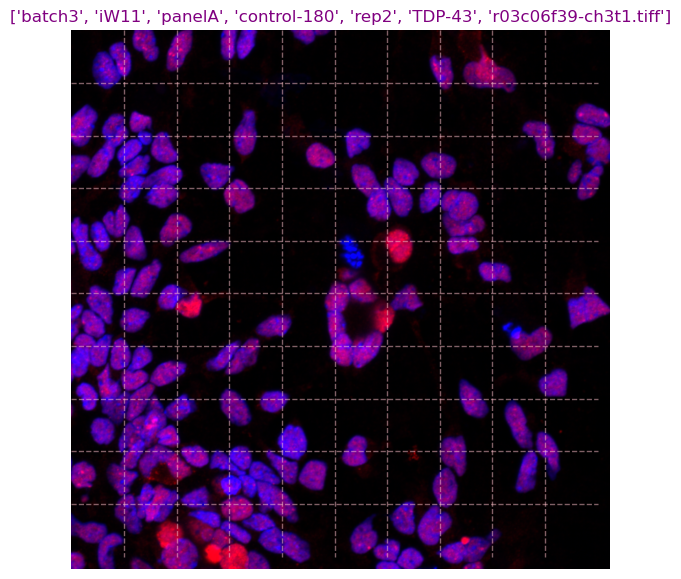

----------------------------------------------------------------------------------------------------
1
Image path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch3/iW11/panelA/ranbp17-kd/rep2/TDP-43/r03c03f14-ch3t1.tiff
Brenner percentile: 95.40816326530613%
DAPI path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch3/iW11/panelA/ranbp17-kd/rep2/DAPI/r03c03f14-ch2t1.tiff


Cropping image to fit


Brenner: 3681.874


Cropping image to fit


Img shape: (1024, 1024)


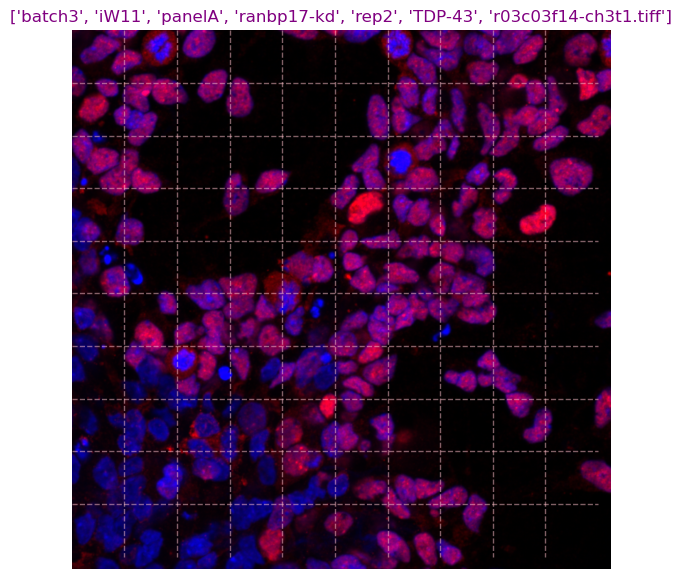

----------------------------------------------------------------------------------------------------
2
Image path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch3/iW11/panelA/control-180/rep1/TDP-43/r02c06f32-ch3t1.tiff
Brenner percentile: 98.46938775510205%
DAPI path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch3/iW11/panelA/control-180/rep1/DAPI/r02c06f32-ch2t1.tiff


Cropping image to fit
Cropping image to fit


Brenner: 3739.523
Img shape: (1024, 1024)


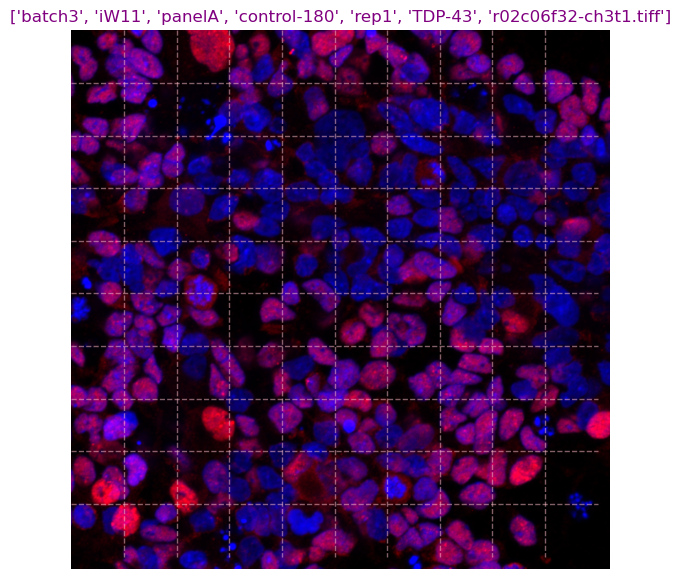

Cropping image to fit


----------------------------------------------------------------------------------------------------
3
Image path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch3/iW11/panelA/ranbp17-kd/rep1/TDP-43/r02c03f01-ch3t1.tiff
Brenner percentile: 98.63945578231292%
DAPI path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch3/iW11/panelA/ranbp17-kd/rep1/DAPI/r02c03f01-ch2t1.tiff
Brenner: 2601.093


Cropping image to fit


Img shape: (1024, 1024)


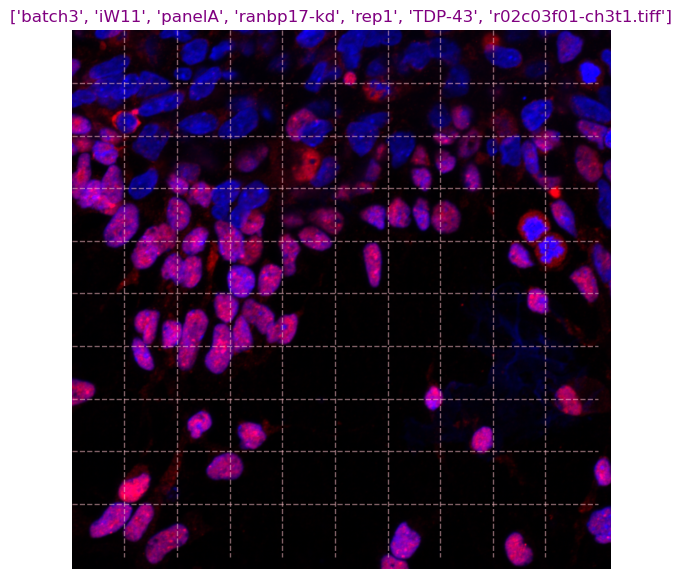

----------------------------------------------------------------------------------------------------
4
Image path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch3/iW11/panelA/control-180/rep2/TDP-43/r03c06f13-ch3t1.tiff
Brenner percentile: 97.61904761904762%
DAPI path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch3/iW11/panelA/control-180/rep2/DAPI/r03c06f13-ch2t1.tiff


Cropping image to fit
Cropping image to fit


Brenner: 2999.324
Img shape: (1024, 1024)


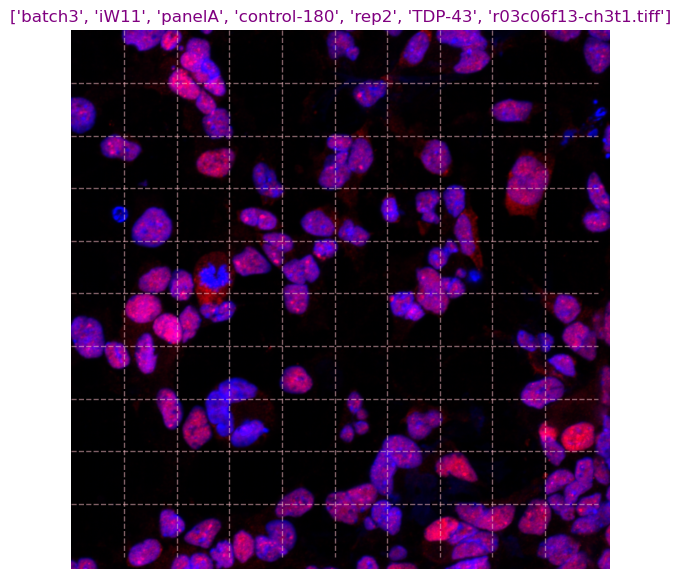

----------------------------------------------------------------------------------------------------
5
Image path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch3/iW11/panelA/ranbp17-kd/rep2/TDP-43/r03c03f20-ch3t1.tiff
Brenner percentile: 95.74829931972789%
DAPI path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch3/iW11/panelA/ranbp17-kd/rep2/DAPI/r03c03f20-ch2t1.tiff


Cropping image to fit


Brenner: 2393.196


Cropping image to fit


Img shape: (1024, 1024)


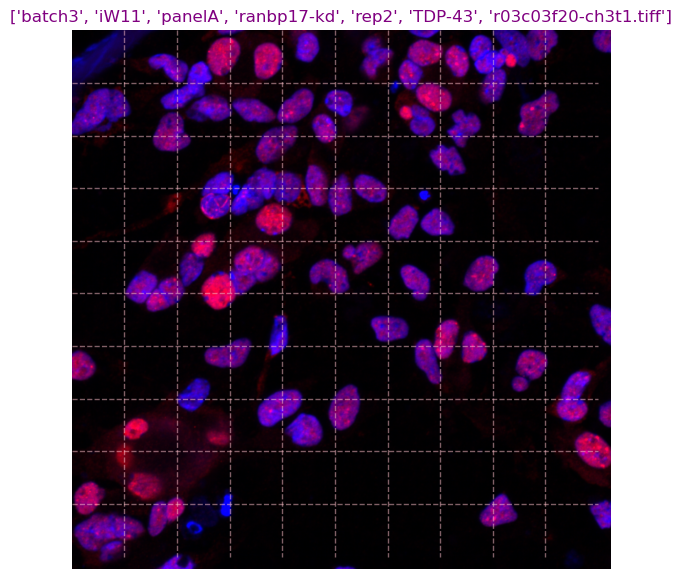

----------------------------------------------------------------------------------------------------
6
Image path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch3/iW11/panelA/untreated/rep1/TDP-43/r02c07f09-ch3t1.tiff
Brenner percentile: 96.25850340136054%
DAPI path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch3/iW11/panelA/untreated/rep1/DAPI/r02c07f09-ch2t1.tiff


Cropping image to fit


Brenner: 3068.407


Cropping image to fit


Img shape: (1024, 1024)


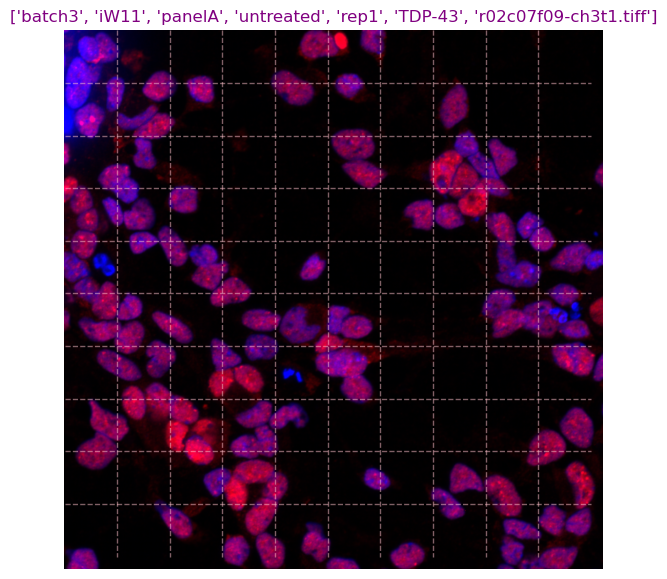

----------------------------------------------------------------------------------------------------
7
Image path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch3/iW11/panelA/control-179/rep1/TDP-43/r02c05f31-ch3t1.tiff
Brenner percentile: 96.93877551020408%
DAPI path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch3/iW11/panelA/control-179/rep1/DAPI/r02c05f31-ch2t1.tiff


Cropping image to fit


Brenner: 2397.114


Cropping image to fit


Img shape: (1024, 1024)


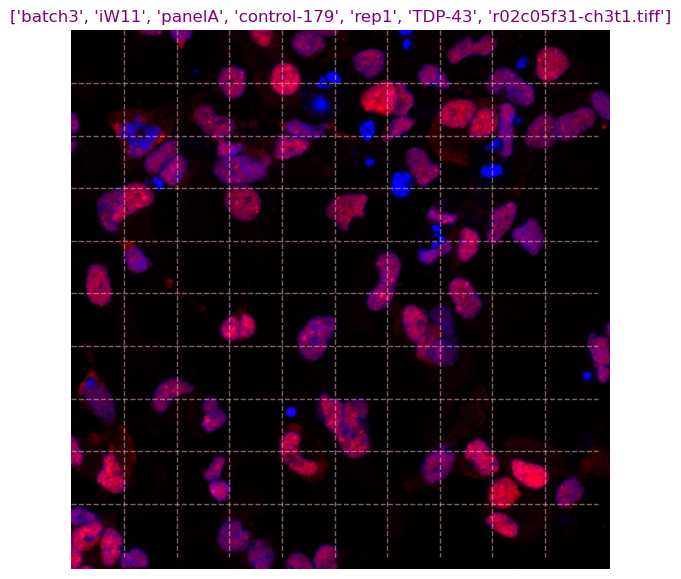

----------------------------------------------------------------------------------------------------
8
Image path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch3/iW11/panelA/ranbp17-kd/rep2/TDP-43/r03c03f07-ch3t1.tiff
Brenner percentile: 96.42857142857143%
DAPI path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch3/iW11/panelA/ranbp17-kd/rep2/DAPI/r03c03f07-ch2t1.tiff


Cropping image to fit
Cropping image to fit


Brenner: 3505.306
Img shape: (1024, 1024)


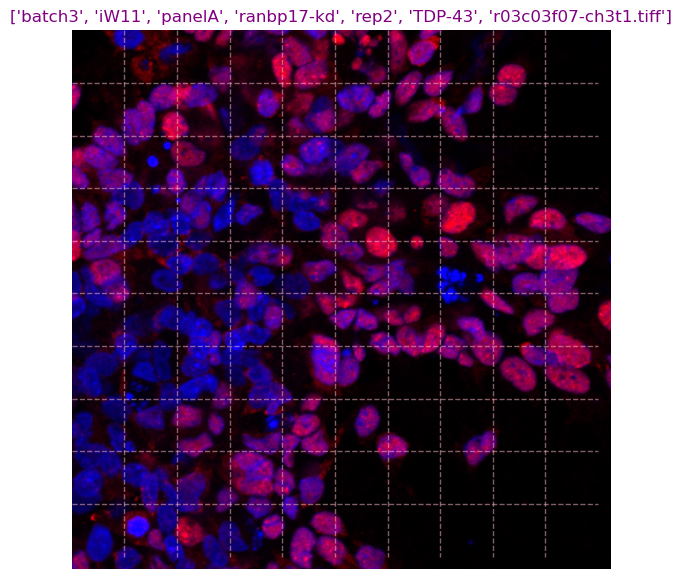

----------------------------------------------------------------------------------------------------
9
Image path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch3/iW11/panelA/ranbp17-kd/rep2/TDP-43/r03c03f48-ch3t1.tiff
Brenner percentile: 99.14965986394559%
DAPI path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch3/iW11/panelA/ranbp17-kd/rep2/DAPI/r03c03f48-ch2t1.tiff


Cropping image to fit


Brenner: 3388.58


Cropping image to fit


Img shape: (1024, 1024)


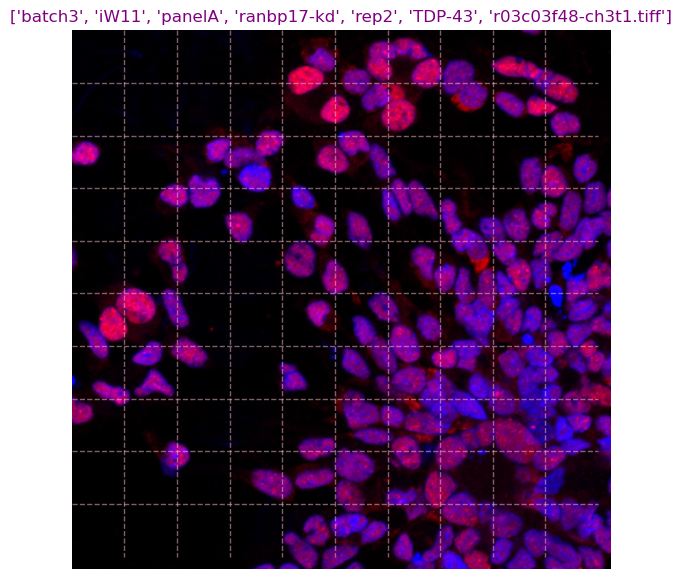

Cropping image to fit


----------------------------------------------------------------------------------------------------
10
Image path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch3/iW11/panelA/ranbp17-kd/rep2/TDP-43/r03c03f22-ch3t1.tiff
Brenner percentile: 99.65986394557824%
DAPI path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch3/iW11/panelA/ranbp17-kd/rep2/DAPI/r03c03f22-ch2t1.tiff


Cropping image to fit


Brenner: 4304.59
Img shape: (1024, 1024)


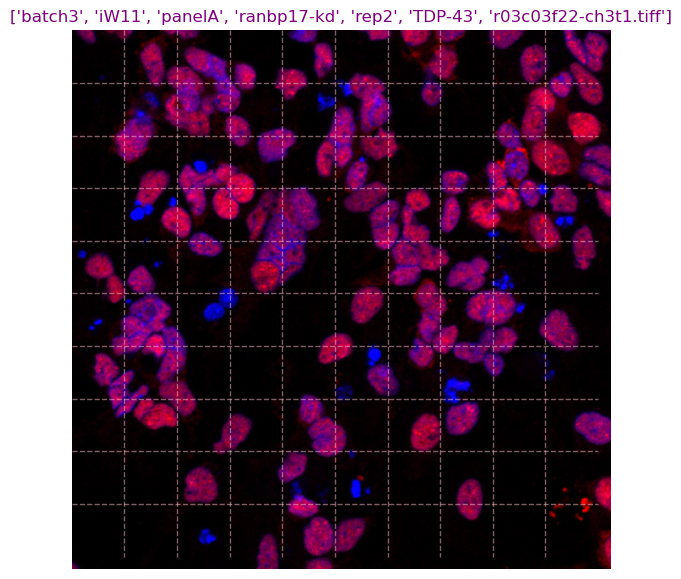

Cropping image to fit


----------------------------------------------------------------------------------------------------
11
Image path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch3/iW11/panelA/control-180/rep1/TDP-43/r02c06f49-ch3t1.tiff
Brenner percentile: 97.78911564625851%
DAPI path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/sorted/batch3/iW11/panelA/control-180/rep1/DAPI/r02c06f49-ch2t1.tiff
Brenner: 2634.918


Cropping image to fit


Img shape: (1024, 1024)


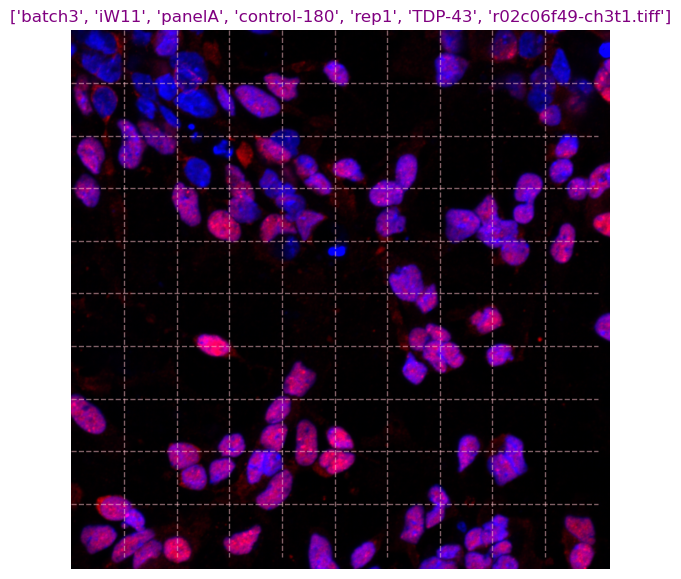

----------------------------------------------------------------------------------------------------
12
Stopping at 12. There are 30 images in total


In [59]:
#################### SAFE ZONE TO CHANGE ###############
per_min = 95 # show images from this percentile and above
per_max = 100 # show images up to this percentile
batch=[BATCH]
rep=None
cell_line=None

###################### END OF SAFE ZONE ###################


df_marker = df.loc[df['Marker'] == marker]
marker_max_value = df_marker[metric_name].max()

percentiles = df_marker[metric_name].describe(percentiles=percentiles_to_describe)

print(f'Showing images between %{per_min} - {per_max}')
threshold = percentiles[f'{per_min}%']
threshold_second = percentiles[f'{per_max}%']

df_marker["brenner_percentile"] = (
    df_marker[metric_name].rank(pct=True) * 100
)

c = (df_marker[metric_name]>=threshold) & (df_marker[metric_name]<=threshold_second) 

# threshold
df_marker_filtered = df_marker[c]
# shuffle
df_marker_filtered = df_marker_filtered.sample(frac=1, random_state=1)
# df_marker_filtered.index = range(len(df_marker_filtered))

print(f"Number of {marker} images in threshold {threshold} ({per_min}%) (and {threshold_second} ({per_max}%)): {len(df_marker_filtered)}")
# print("\n")
# print(df_marker_filtered['CellLine'].value_counts().to_string())
# print("\n")
# print(df_marker_filtered['Condition'].value_counts().to_string())
print("\n")
show_images(df_marker_filtered, marker_name=marker, max_samples=max_samples, lower_bound=lower_bound, upper_bound=upper_bound, dapi_lower_bound=dapi_lower_bound, dapi_upper_bound=dapi_upper_bound)

2. Setting Brenners in the csv

# Save thresholds

In [60]:
# print mappings_filepath
mappings_filepath

'/home/projects/hornsteinlab/giliwo/NOVA/manuscript/markers_focus_boundries/markers_focus_boundries_RANBP17_exp_batch3.csv'

In [61]:
# print thresholds to be saved
thresholds


{'DAPI': (0, 100), 'RANBP17': (0, 100), 'TDP-43': (0, 100)}

In [62]:
mappings = update_all_mappings(mappings, thresholds, df)
print(mappings)

        Lower_bound Upper_bound
DAPI           23.0     2000.34
RANBP17       10.98     1456.61
TDP-43        14.32     1821.69


In [63]:
if SAVE_THRESHOLDs:
    # update the mappings

    mappings.to_csv(mappings_filepath)

    print("Saved mappings to:", mappings_filepath)
    print("mappings saved:")
    mappings

Saved mappings to: /home/projects/hornsteinlab/giliwo/NOVA/manuscript/markers_focus_boundries/markers_focus_boundries_RANBP17_exp_batch3.csv
mappings saved:
